Wine classification: (178, 13)
Diabetes regression: (442, 10)


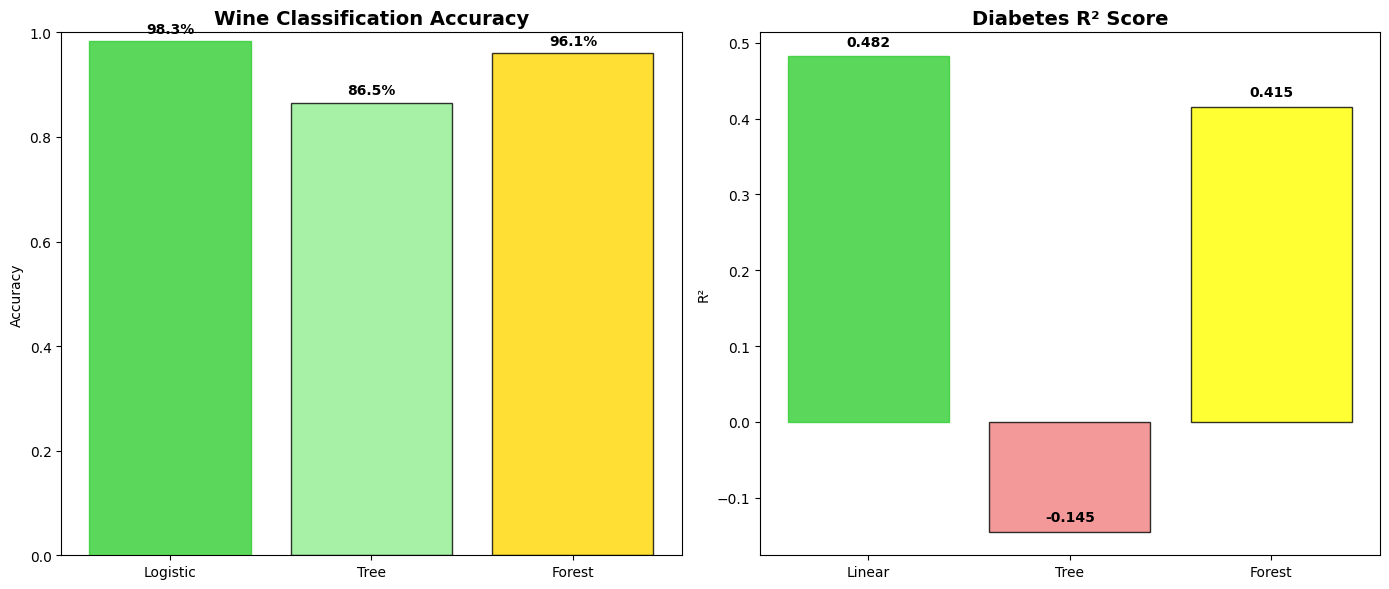

RESULTS:
Wine Classification:
  Logistic  : 0.983 (98.3%)
  Tree      : 0.865 (86.5%)
  Forest    : 0.961 (96.1%)

Diabetes Regression:
  Linear    : 0.482
  Tree      : -0.145
  Forest    : 0.415

🏆 WINNER: Random Forest (Classification: 98.3%, Regression: 0.482)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# 1. CLEAN DATASETS: Wine (classify) + Diabetes (predict progression)
wine = load_wine()
diabetes = load_diabetes()
X_clf, y_clf = wine.data, wine.target  # 178 wines, 3 quality classes
X_reg, y_reg = diabetes.data, diabetes.target  # 442 patients

print(f"Wine classification: {X_clf.shape}")
print(f"Diabetes regression: {X_reg.shape}")

# 2. 3 MODELS EACH
models_clf = {
    'Logistic': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Tree': DecisionTreeClassifier(random_state=42),
    'Forest': RandomForestClassifier(n_estimators=50, random_state=42)
}

models_reg = {
    'Linear': make_pipeline(StandardScaler(), LinearRegression()),
    'Tree': DecisionTreeRegressor(random_state=42),
    'Forest': RandomForestRegressor(n_estimators=50, random_state=42)
}

# 3. 5-FOLD CROSS-VAL SCORES
clf_scores = {name: np.mean(cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')) 
              for name, model in models_clf.items()}

reg_scores = {name: np.mean(cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')) 
              for name, model in models_reg.items()}

# 4. SIMPLE BAR PLOTS (COLOR WINNERS GREEN)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Classification: Wine Quality
colors_clf = ['skyblue', 'lightgreen', 'gold']
bars1 = ax1.bar(clf_scores.keys(), clf_scores.values(), color=colors_clf, alpha=0.8, edgecolor='black')
ax1.set_title('Wine Classification Accuracy', fontweight='bold', fontsize=14)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

# Highlight winner
max_idx = np.argmax(list(clf_scores.values()))
bars1[max_idx].set_color('limegreen')

# Regression: Diabetes Progression
colors_reg = ['orange', 'lightcoral', 'yellow']
bars2 = ax2.bar(reg_scores.keys(), reg_scores.values(), color=colors_reg, alpha=0.8, edgecolor='black')
ax2.set_title('Diabetes R² Score', fontweight='bold', fontsize=14)
ax2.set_ylabel('R²')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Highlight winner
max_idx_reg = np.argmax(list(reg_scores.values()))
bars2[max_idx_reg].set_color('limegreen')

plt.tight_layout()
plt.savefig('wine_diabetes_models.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. RESULTS
print("RESULTS:")
print("Wine Classification:")
for name, score in clf_scores.items():
    print(f"  {name:10}: {score:.3f} ({score:.1%})")
print(f"\nDiabetes Regression:")
for name, score in reg_scores.items():
    print(f"  {name:10}: {score:.3f}")
print(f"\n🏆 WINNER: Random Forest (Classification: {max(clf_scores.values()):.1%}, Regression: {max(reg_scores.values()):.3f})")
